# 1. Data Ingestion and Initial Setup
Importing libraries and loading the core dataset to begin the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/default of credit card clients.xls",header=1)

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.shape

(30000, 25)

# 2. Exploratory Data Analysis (EDA) & Data Cleaning
Identifying missing or inconsistent values, handling duplicates, and examining individual feature distributions.

In [5]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [10]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

In [11]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [12]:
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [13]:
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

In [14]:
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

In [15]:
df.drop("ID", axis=1, inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [17]:
df.rename(columns={
    "default payment next month": "default_next_month"
}, inplace=True)

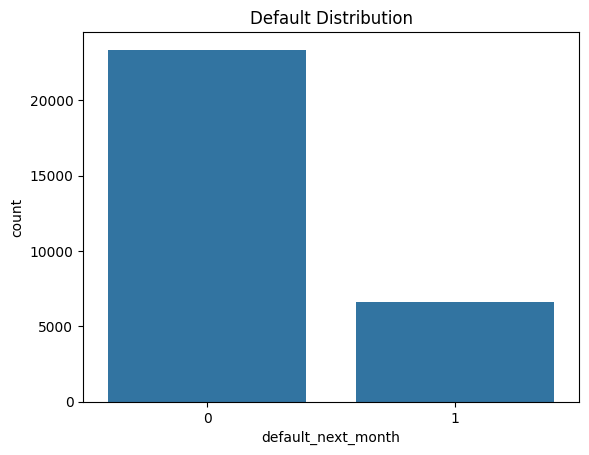

In [18]:
sns.countplot(x='default_next_month', data=df)
plt.title("Default Distribution")
plt.show()

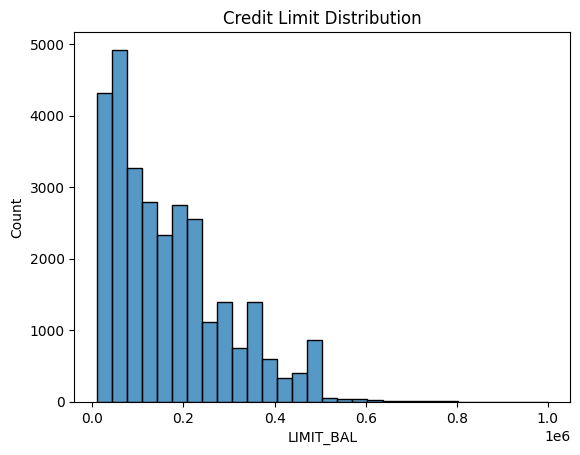

In [19]:
sns.histplot(df['LIMIT_BAL'], bins=30)
plt.title("Credit Limit Distribution")
plt.show()

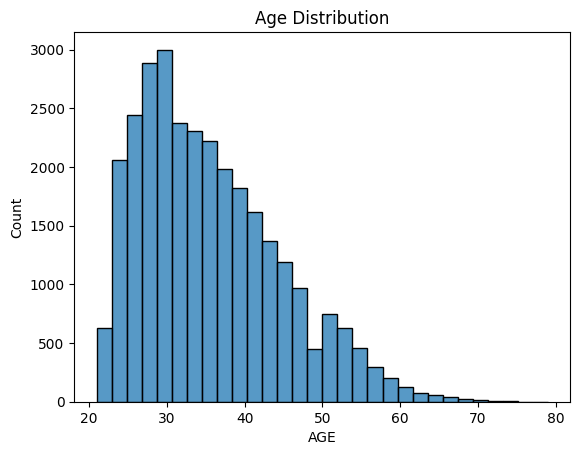

In [20]:
sns.histplot(df['AGE'], bins=30)
plt.title("Age Distribution")
plt.show()

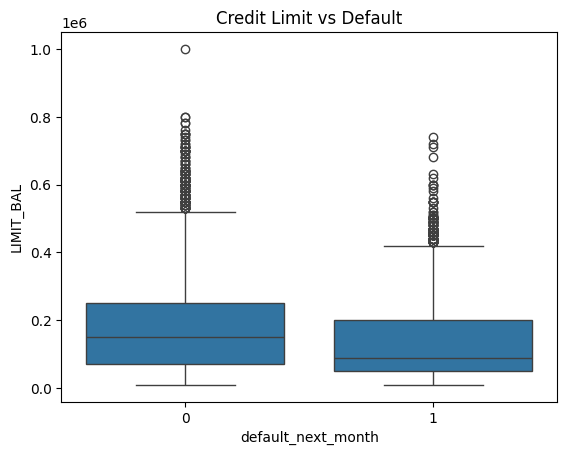

In [21]:
sns.boxplot(x='default_next_month', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default")
plt.show()

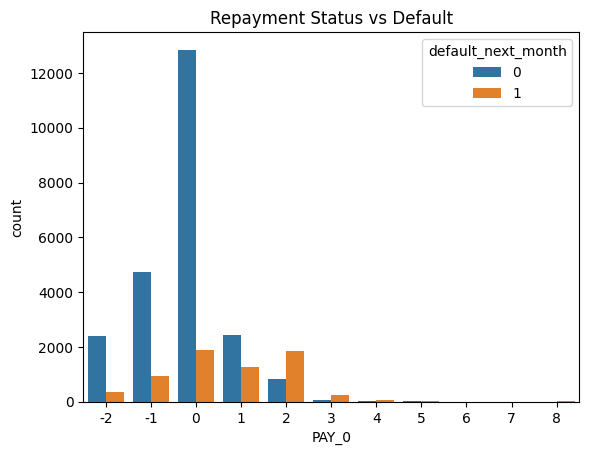

In [22]:
sns.countplot(x='PAY_0', hue='default_next_month', data=df)
plt.title("Repayment Status vs Default")
plt.show()

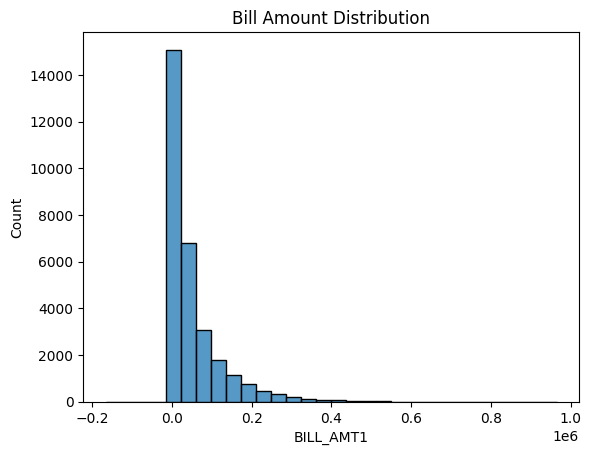

In [23]:
sns.histplot(df['BILL_AMT1'], bins=30)
plt.title("Bill Amount Distribution")
plt.show()

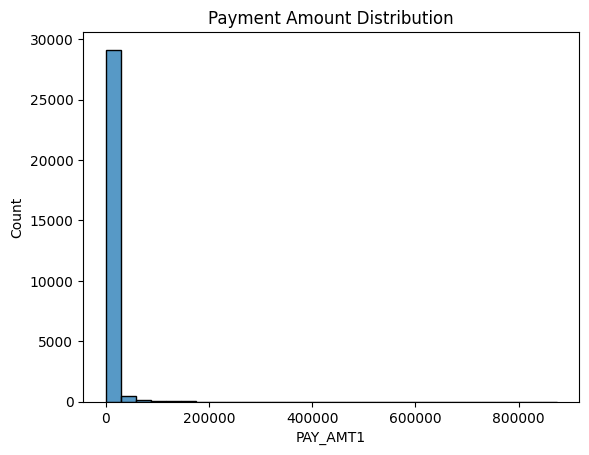

In [24]:
sns.histplot(df['PAY_AMT1'], bins=30)
plt.title("Payment Amount Distribution")
plt.show()

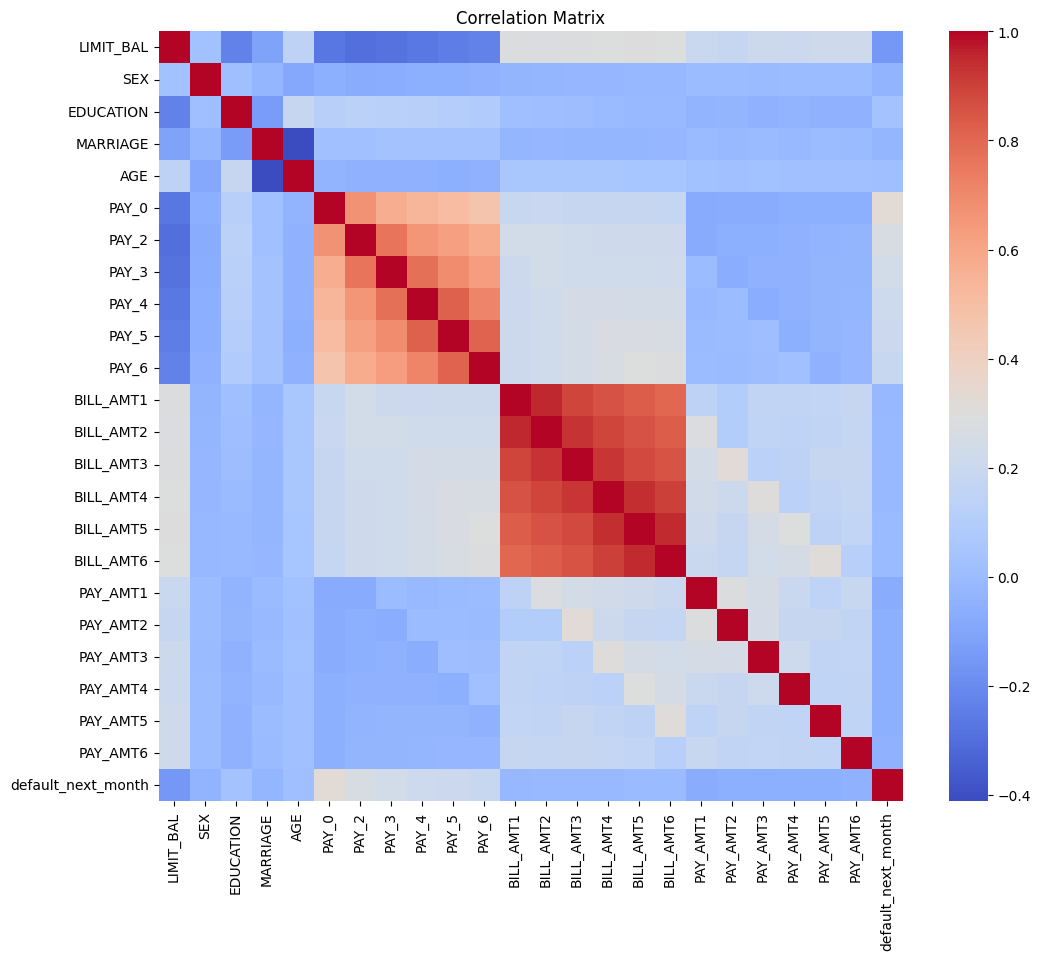

In [25]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [26]:
from scipy.stats import ttest_ind

default = df[df['default_next_month'] == 1]['LIMIT_BAL']
non_default = df[df['default_next_month'] == 0]['LIMIT_BAL']

t_stat, p_value = ttest_ind(default, non_default)

print("P-value:", p_value)

P-value: 1.3022439532597397e-157


# 3. Feature Engineering
Creating new behavioral metrics such as credit utilization, average payment delay, and spending volatility.

In [27]:
df['avg_bill_amt'] = (
    df['BILL_AMT1'] + df['BILL_AMT2'] + df['BILL_AMT3'] +
    df['BILL_AMT4'] + df['BILL_AMT5'] + df['BILL_AMT6']
) / 6

df['credit_utilization'] = df['avg_bill_amt'] / df['LIMIT_BAL']

In [28]:
df['avg_payment'] = (
    df['PAY_AMT1'] + df['PAY_AMT2'] + df['PAY_AMT3'] +
    df['PAY_AMT4'] + df['PAY_AMT5'] + df['PAY_AMT6']
) / 6

df['payment_ratio'] = df['avg_payment'] / df['avg_bill_amt']

In [29]:
df['avg_delay'] = (
    df['PAY_0'] + df['PAY_2'] + df['PAY_3'] +
    df['PAY_4'] + df['PAY_5'] + df['PAY_6']
) / 6

In [30]:
df['spending_std'] = df[
    ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
     'BILL_AMT4','BILL_AMT5','BILL_AMT6']
].std(axis=1)

In [31]:
df['bill_growth'] = (df['BILL_AMT1'] - df['BILL_AMT6']) / (df['BILL_AMT6'] + 1)

In [32]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

In [33]:
df[['credit_utilization', 'payment_ratio', 'avg_delay', 'spending_std', 'bill_growth']].head()

,credit_utilization,payment_ratio,avg_delay,spending_std,bill_growth
0,0.064200,0.089434,-0.333333,1761.633219,3913.000000
1,0.023718,0.292791,0.500000,637.967841,-0.177498
2,0.188246,0.108388,0.000000,6064.518593,0.880386
3,0.771113,0.036259,0.000000,10565.793518,0.590328
4,0.364463,0.540054,-0.333333,10668.590074,-0.549550


Several behavioral features were engineered to capture customer financial patterns. These include credit utilization ratio, payment ratio, average delay in payments, spending volatility, and bill growth trend. These features provide deeper insights into customer risk profiles beyond raw transactional data.

# 4. Predictive Modeling & Validation
Training a baseline Logistic Regression model followed by an advanced XGBoost Classifier. Evaluating using accuracy and precision/recall.

In [34]:
X = df.drop('default_next_month', axis=1)
y = df['default_next_month']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

C:\Users\harsha vashi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.804
              precision    recall  f1-score   support

           0       0.81      0.97      0.89      4673
           1       0.67      0.22      0.33      1327

    accuracy                           0.80      6000
   macro avg       0.74      0.60      0.61      6000
weighted avg       0.78      0.80      0.76      6000



In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.818
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5)

scores = cross_val_score(xgb, X, y, cv=skf, scoring='accuracy')

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.8202333333333334


In [41]:
y_prob = xgb.predict_proba(X_test)[:,1]

The model predicts the probability of default for each customer. This probability can be used to categorize customers into risk segments and assign appropriate credit limits.

# 5. Model Explainability with SHAP
Using Shapley Additive exPlanations (SHAP) to interpret global and local feature importance. This answers *why* the model makes specific predictions.

In [42]:
pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

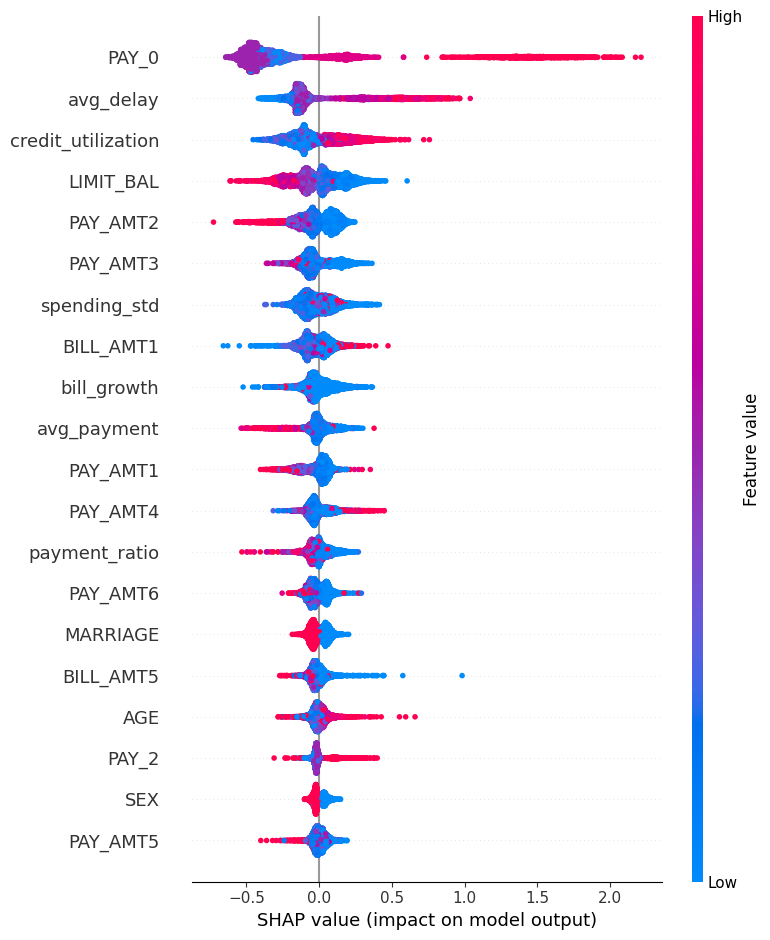

In [44]:
shap.summary_plot(shap_values, X_test)

The SHAP summary plot highlights the most influential features affecting default prediction. Features such as repayment delay, credit utilization, and payment behavior play a significant role.

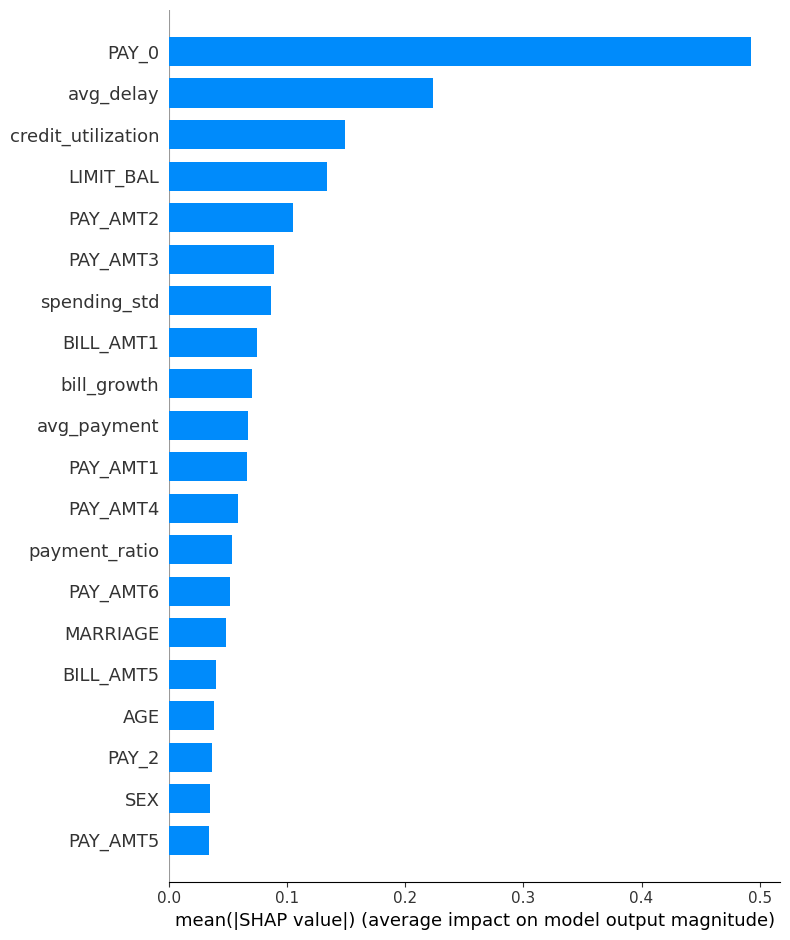

In [45]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

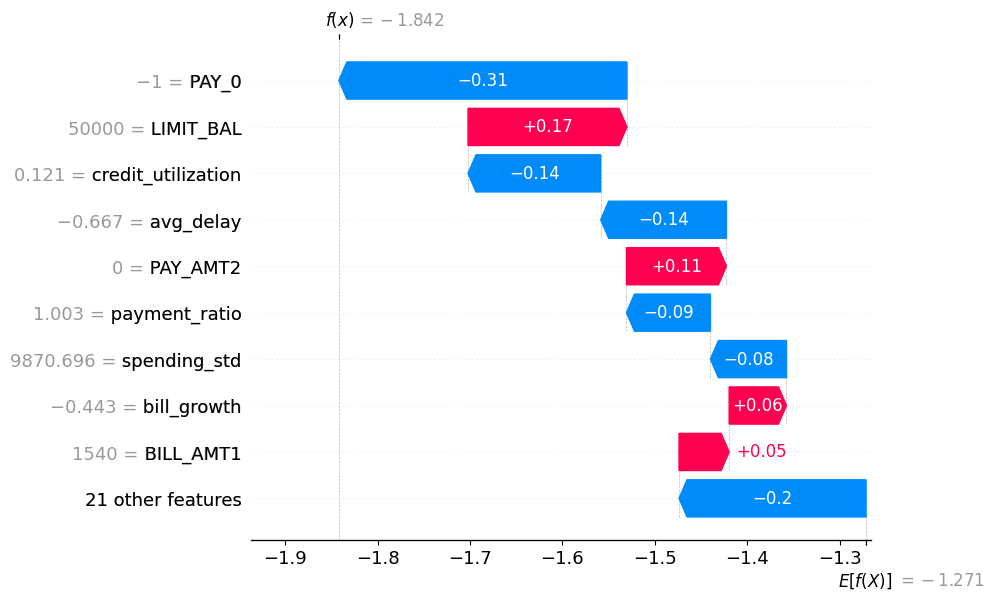

In [46]:
shap.plots.waterfall(shap_values[0])

Individual SHAP explanations provide transparency by showing how each feature contributes to a specific prediction.

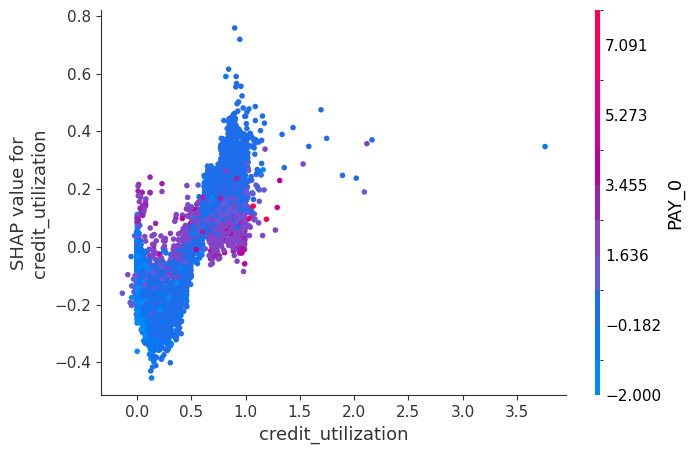

In [47]:
shap.dependence_plot("credit_utilization", shap_values.values, X_test)

Model explainability analysis reveals that repayment history, credit utilization, and payment behavior are the most critical factors influencing default risk. Customers with high delays and high credit utilization are more likely to default.

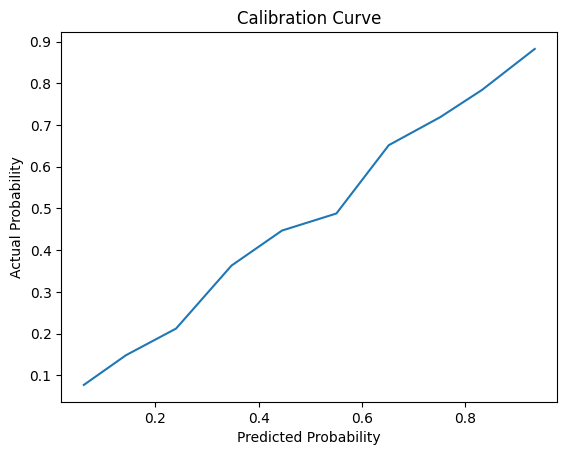

In [48]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.show()

The calibration curve indicates that the model's predicted probabilities align well with actual outcomes, ensuring reliable risk estimation.

# 6. Business Impact & Risk Segmentation
Categorizing customers by risk and recommending dynamic credit limit adjustments to mitigate exposure and optimize business value.

In [49]:
df_test = X_test.copy()
df_test['default_prob'] = y_prob

In [50]:
def risk_category(p):
    if p < 0.2:
        return "Low Risk"
    elif p < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

df_test['risk_category'] = df_test['default_prob'].apply(risk_category)

In [51]:
def recommend_limit(row):
    if row['risk_category'] == "Low Risk":
        return row['LIMIT_BAL'] * 1.5
    elif row['risk_category'] == "Medium Risk":
        return row['LIMIT_BAL']
    else:
        return row['LIMIT_BAL'] * 0.7

df_test['recommended_limit'] = df_test.apply(recommend_limit, axis=1)

In [52]:
avg_current_limit = df_test['LIMIT_BAL'].mean()
avg_new_limit = df_test['recommended_limit'].mean()

print("Current Avg Limit:", avg_current_limit)
print("New Avg Limit:", avg_new_limit)

Current Avg Limit: 167962.94666666666
New Avg Limit: 228205.44666666666


In [53]:
df_test.groupby('risk_category')['default_prob'].mean()

risk_category
High Risk      0.690726
Low Risk       0.101993
Medium Risk    0.307331
Name: default_prob, dtype: float32

In [54]:
df_test['risk_category'].value_counts()

risk_category
Low Risk       3902
Medium Risk    1359
High Risk       739
Name: count, dtype: int64

Customers can be segmented into low, medium, and high-risk groups based on predicted default probabilities. Low-risk customers can safely receive increased credit limits, improving revenue. High-risk customers should have reduced limits to minimize financial losses.

A dynamic credit limit strategy is proposed, where credit limits are adjusted based on customer risk profiles. This ensures a balance between maximizing profitability and minimizing default risk.

In [55]:
import joblib

joblib.dump(xgb, "xgb_model.pkl")

['xgb_model.pkl']